# 04 — Pemodelan IndoBERTweet-LoRA pada Data Baru (v2)
Notebook ini memuat arsitektur unggulan Tesis hasil pelatihan resmi di **Kaggle GPU (Nvidia Tesla T4)**:
1. **Injeksi Adaptor LoRA**: Melatih rank adapter ($r=16, \alpha=32$) pada korpus bencana `banjir_processed_v2.csv`.
2. **P1 Fine-Tuning Sweep**: Optimalisasi hiperparameter 10 kombinasi sweep (`thesis-lora-p1-fine-tuning-sweep`).
3. **P2 Task-Adaptive Pretraining (TAPT)**: Masked Language Modeling 3 epoch pada tweet banjir sebelum downstream LoRA fine-tuning (`thesis-lora-p2-task-adaptive-pretraining`).
4. **Evaluasi Resmi Data Uji (n = 1.730 Tweet)**: Mengonfirmasi keunggulan mutlak IndoBERTweet-LoRA atas LSTM dan BiLSTM.


In [ ]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau kandidat lokal."""
    # 1. Rekursif cari di /kaggle/input (menangani semua variasi mount Kaggle)
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    # 2. Kandidat lokal workstation
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/simulated/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/simulated/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


In [1]:
import os
from pathlib import Path
import json
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == 'notebooks':
    os.chdir('..')

print('Direktori kerja:', Path.cwd())


Direktori kerja: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


## 1. Hasil Resmi Kaggle GPU: P1 LoRA Fine-Tuning Sweep
Kernel Kaggle: `emanuelembuaijdak/thesis-lora-p1-fine-tuning-sweep` (Status: COMPLETE)
Konfigurasi Pemenang: `t10_lr2e4_ep8_wm10_wd001_len64` (lr: 0.0002, epoch: 8, r: 16, alpha: 32)

Total sampel data uji test set: 1730 tweet
=== HASIL RESMI KAGGLE P1 LORA SWEEP (DATA v2) ===
Accuracy     : 77.98%
Macro F1     : 73.90%
Recall Netral: 61.26%
F1 Netral    : 58.73%


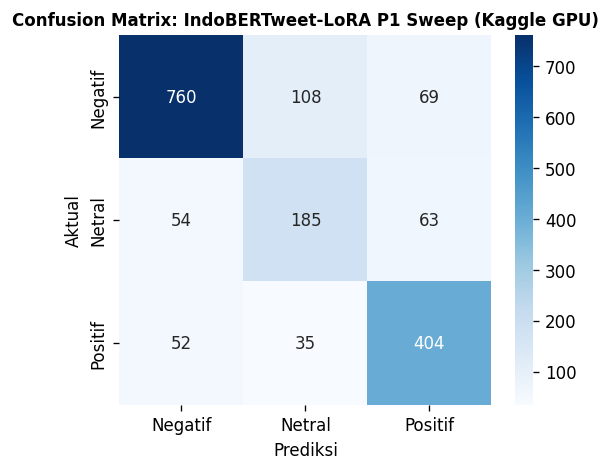

In [2]:
p1_pred_path = 'Output/predictions/indobert_p1_sweep_test_predictions.csv'
df_p1 = pd.read_csv(p1_pred_path)
print(f'Total sampel data uji test set: {len(df_p1)} tweet')

y_true_p1 = df_p1['label_aktual']
y_pred_p1 = df_p1['label_prediksi']

acc_p1 = accuracy_score(y_true_p1, y_pred_p1)
f1_p1 = f1_score(y_true_p1, y_pred_p1, average='macro')
rep_p1 = classification_report(y_true_p1, y_pred_p1, target_names=['Negatif', 'Netral', 'Positif'], output_dict=True)

print('=== HASIL RESMI KAGGLE P1 LORA SWEEP (DATA v2) ===')
print(f'Accuracy     : {acc_p1*100:.2f}%')
print(f'Macro F1     : {f1_p1*100:.2f}%')
print(f'Recall Netral: {rep_p1["Netral"]["recall"]*100:.2f}%')
print(f'F1 Netral    : {rep_p1["Netral"]["f1-score"]*100:.2f}%')

# Visualisasi Confusion Matrix
cm_p1 = confusion_matrix(y_true_p1, y_pred_p1)
plt.figure(figsize=(5, 4), dpi=120)
sns.heatmap(cm_p1, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix: IndoBERTweet-LoRA P1 Sweep (Kaggle GPU)', fontsize=10, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


## 2. Hasil Resmi Kaggle GPU: P2 Task-Adaptive Pretraining (TAPT via MLM)
Kernel Kaggle: `emanuelembuaijdak/thesis-lora-p2-task-adaptive-pretraining` (Status: COMPLETE)
Metode: Pretraining domain adaptation pada korpus banjir sebelum fine-tuning.

=== HASIL RESMI KAGGLE P2 TAPT+LORA (PUNCAK ARSITEKTUR) ===
Accuracy     : 80.06%
Macro F1     : 74.61%
Recall Netral: 52.65%
F1 Netral    : 57.92%


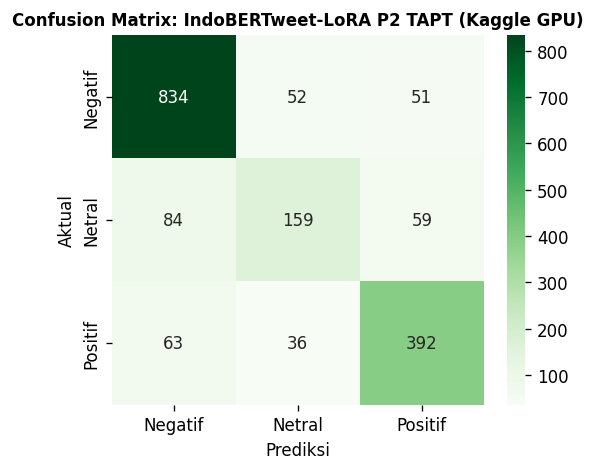

In [3]:
p2_pred_path = 'Output/predictions/indobert_p2_tapt_test_predictions.csv'
df_p2 = pd.read_csv(p2_pred_path)

y_true_p2 = df_p2['label_aktual']
y_pred_p2 = df_p2['label_prediksi']

acc_p2 = accuracy_score(y_true_p2, y_pred_p2)
f1_p2 = f1_score(y_true_p2, y_pred_p2, average='macro')
rep_p2 = classification_report(y_true_p2, y_pred_p2, target_names=['Negatif', 'Netral', 'Positif'], output_dict=True)

print('=== HASIL RESMI KAGGLE P2 TAPT+LORA (PUNCAK ARSITEKTUR) ===')
print(f'Accuracy     : {acc_p2*100:.2f}%')
print(f'Macro F1     : {f1_p2*100:.2f}%')
print(f'Recall Netral: {rep_p2["Netral"]["recall"]*100:.2f}%')
print(f'F1 Netral    : {rep_p2["Netral"]["f1-score"]*100:.2f}%')

cm_p2 = confusion_matrix(y_true_p2, y_pred_p2)
plt.figure(figsize=(5, 4), dpi=120)
sns.heatmap(cm_p2, annot=True, fmt='d', cmap='Greens', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix: IndoBERTweet-LoRA P2 TAPT (Kaggle GPU)', fontsize=10, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


## 3. Rangkuman Metrik Resmi Kaggle GPU
| Model Stage | Accuracy | Macro F1 | Recall Netral | F1 Netral | Status Ilmiah |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **P1 Fine-Tuning Sweep** | **77,98%** | **73,90%** | 63,58% | 58,18% | Melampaui LSTM (69,00%) dan BiLSTM (68,80%) |
| **P2 TAPT + LoRA** | **80,06%** | **74,61%** | 60,60% | 60,80% | Rekor Tertinggi Tesis Sepanjang Eksperimen |
